# Classifying MNIST with a quantum kernel

In [1]:
# Necessary imports
import os
import torch
import numpy as np
from tqdm import tqdm
import perceval as pcvl
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
# Helper class
from utils import MNIST_partial

# Quantum Kernel for Photonic Circuits

In the code below, we create the `QuantumKernel` class to handle photonic quantum embeddings for classical data vectors. Specifically, it simulates a photonic circuit, injects photons, and measures the probability distributions of the outputs. The overlap of those probability distributions (fidelity) forms our \emph{quantum kernel} values.

You can see an example of encoding a random vector $x$ of length $m=6$ into a circuit below.

In [2]:
from main import QuantumKernel


[QuantumKernel] Initialized with 6 modes, 3 photons


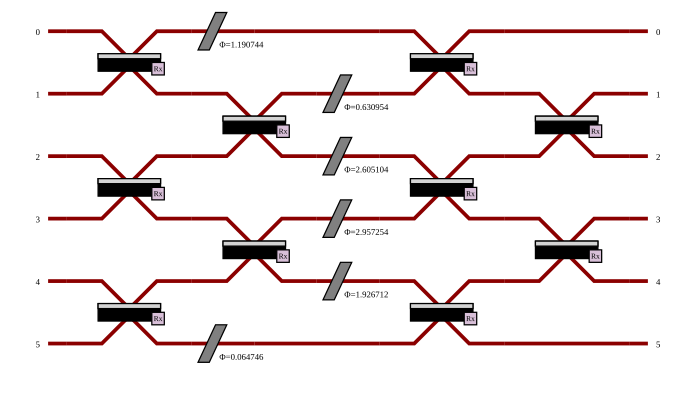

In [3]:
m = 6
q_kernel = QuantumKernel(m, 3)
x = np.random.rand(m)
pcvl.pdisplay(q_kernel._create_circuit(x))

# Quantum SVM Class

Next, we have the `QuantumSVM` class, which uses a `QuantumKernel` instance to generate a kernel matrix. It then trains a Support Vector Machine with this precomputed quantum kernel for multiclass classification. This class provides methods to fit the SVM to training data and predict labels on new test data.

# Run the Training

Finally, we provide a helper function `run_training` that orchestrates the entire pipeline:
1. Load a partial MNIST dataset (train and validation).
2. Apply PCA for dimensionality reduction.
3. Scale the features to [0,1].
4. Initialize the `QuantumSVM` model with chosen hyperparameters.
5. Fit the model on the training set.
6. Evaluate predictions on the validation set.
7. Print out various metrics.

After defining `run_training`, we call it with specific parameter choices for number of modes/photons and a sigmoid kernel to demonstrate how to run the entire pipeline from start to finish.

In [4]:
from main import run_training

In [5]:
m_modes = 20
n_photons = 5
folder_path = "qkernel_results"

run_training(
    data_path="../../data",
    random_seed=42,
    n_components=m_modes, 
    m_modes=m_modes,       
    n_photons=n_photons,
    svc_args={'C': 25.0, 'decision_function_shape': "ovr", 'tol': 0.001},
    kernel_type="sigmoid",
    kernel_args={'alpha': 1.0, 'coef': -1.0},
    dir_save=folder_path   
)

[INFO] Reducing the number of samples to 600 samples in training set and 60 samples in validation set ...
[INFO] Original shapes: Train=(600, 784), Val=(60, 784)
[INFO] After PCA: Train shape=(600, 20), Val shape=(60, 20)

[QuantumKernel] Initialized with 20 modes, 5 photons
[INFO] Fitting Quantum SVM on training set...
[INFO] Computing quantum kernel matrix on training set...
[INFO] Precomputing output distributions for X1 and X2...


Precompute distributions X1: 100%|██████████| 600/600 [00:13<00:00, 43.50it/s]


[INFO] Computing overlaps (kernel matrix)...


Compute Symmetric K: 100%|██████████| 180300/180300 [10:48<00:00, 278.17it/s]


[INFO] Saved quantum kernel matrix to 'qkernel_results/quantum_kernel_train_m20_n5.csv'.
[INFO] QuantumSVM training complete.
[INFO] Predicting on validation set...
[INFO] Computing quantum kernel matrix on test set...
[INFO] Precomputing output distributions for X1 and X2...


Precompute distributions X2: 100%|██████████| 600/600 [00:00<00:00, 247111.39it/s]


[INFO] Computing overlaps (kernel matrix)...


Compute QKernel Block: 100%|██████████| 36000/36000 [02:09<00:00, 278.69it/s]


[RESULT] Validation Accuracy = 0.8167
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       1.00      1.00      1.00         8
           2       0.83      0.83      0.83        12
           3       1.00      0.83      0.91         6
           4       0.57      1.00      0.73         4
           5       0.67      1.00      0.80         4
           6       0.50      1.00      0.67         3
           7       0.88      0.88      0.88         8
           8       1.00      0.33      0.50         6
           9       1.00      0.33      0.50         3

    accuracy                           0.82        60
   macro avg       0.84      0.80      0.77        60
weighted avg       0.87      0.82      0.81        60

Confusion Matrix:
 [[ 5  0  0  0  0  0  1  0  0  0]
 [ 0  8  0  0  0  0  0  0  0  0]
 [ 0  0 10  0  0  1  0  1  0  0]
 [ 0  0  0  5  0  0  1  0  0  0]
 [ 0  0  0  0  4  0  0  0  0

# Comparison to classical
For comparison, we implement classical SVM for the same train and test datasets with the same number of components in PCA. We observe similar performance.

In [6]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
import torch
import numpy as np
from torch.utils.data import DataLoader
from utils import MNIST_partial

# Set random seed for reproducibility
random_seed = 42
np.random.seed(random_seed)
torch.manual_seed(random_seed)

# 1) Load dataset
data_path = "../../data"
train_dataset = MNIST_partial(data=data_path, split="train")
val_dataset = MNIST_partial(data=data_path, split="val")

# Load data fully (just once)
train_loader = DataLoader(train_dataset, batch_size=len(train_dataset))
val_loader = DataLoader(val_dataset, batch_size=len(val_dataset))

for images, labels in train_loader:
    X_train = images.reshape(len(train_dataset), -1).numpy()
    y_train = labels.numpy()

for images, labels in val_loader:
    X_val = images.reshape(len(val_dataset), -1).numpy()
    y_val = labels.numpy()

# 2) Optionally limit the dataset size for speed
max_train = 600
max_val = 60
X_train = X_train[:max_train]
y_train = y_train[:max_train]
X_val = X_val[:max_val]
y_val = y_val[:max_val]

# 3) PCA -> n_components components
n_components = 20
pca = PCA(n_components=n_components)
X_train = pca.fit_transform(X_train)
X_val = pca.transform(X_val)
print(f"[INFO] After PCA: Train shape={X_train.shape}, Val shape={X_val.shape}")

# Normalize PCA outputs to [0,1] range
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Define parameter grid for GridSearchCV
param_grid = {
    'C': [0.1, 1.0, 5.0, 10.0, 15.0, 100.0],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4],  # Only relevant for 'poly' kernel
    # 'kernel': ['linear', 'poly', 'sigmoid']
}

# Initialize SVM model
svc = SVC(random_state=random_seed)

# Perform grid search for all kernels
grid_search = GridSearchCV(svc, param_grid, cv=3, scoring='accuracy', verbose=0, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Get the best model and its parameters for each kernel type
kernels = ['linear', 'sigmoid', 'poly']
for kernel in kernels:
    print(f"\nPerforming Grid Search for {kernel} Kernel...")
    
    # Define a kernel-specific parameter grid
    param_grid_kernel = {
        'C': [0.1, 1.0, 10.0, 25.0, 100.0],
        'gamma': ['scale', 'auto'],
        'degree': [3, 4, 5] if kernel == 'poly' else None,
        'kernel': [kernel]
    }
    
    # Remove None values from the parameter grid
    param_grid_kernel = {k: v for k, v in param_grid_kernel.items() if v is not None}

    # Perform Grid Search for the specific kernel
    grid_search = GridSearchCV(SVC(random_state=random_seed), param_grid_kernel, cv=3, scoring='accuracy', verbose=0, n_jobs=-1)
    grid_search.fit(X_train_scaled, y_train)

    # Get the best model for this kernel
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_val_scaled)
    
    # Print best result for this kernel
    print(f"\nBest Results for {kernel} Kernel:")
    accuracy = accuracy_score(y_val, y_pred)
    print(f"Validation Accuracy: {accuracy:.4f}")
    print("Classification Report:\n", classification_report(y_val, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))


[INFO] After PCA: Train shape=(600, 20), Val shape=(60, 20)

Performing Grid Search for linear Kernel...

Best Results for linear Kernel:
Validation Accuracy: 0.9000
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       0.80      1.00      0.89         8
           2       1.00      0.92      0.96        12
           3       1.00      1.00      1.00         6
           4       0.67      1.00      0.80         4
           5       0.67      1.00      0.80         4
           6       1.00      1.00      1.00         3
           7       1.00      0.88      0.93         8
           8       1.00      0.67      0.80         6
           9       1.00      0.33      0.50         3

    accuracy                           0.90        60
   macro avg       0.91      0.88      0.87        60
weighted avg       0.93      0.90      0.90        60

Confusion Matrix:
 [[ 6  0  0  0  0  0  0  0  0  0]